# 交叉驗證 (Cross Validation)

學習目標：
- 了解為什麼需要交叉驗證
- 學會 K-Fold 交叉驗證
- 用交叉驗證比較不同模型

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

## 1. 為什麼需要交叉驗證？

只切一次訓練/測試集的問題：
結果可能因為「切到哪些資料」而有差異。

K-Fold 交叉驗證：
把資料切成 K 份，
輪流用其中 1 份當測試集，其他當訓練集，
重複 K 次，取平均，結果更可靠。

In [2]:
# 建立資料
X, y = make_classification(n_samples=500, n_features=10,
                           random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 三種模型
models = {
    '邏輯迴歸': LogisticRegression(random_state=42),
    '隨機森林': RandomForestClassifier(
                    n_estimators=100, random_state=42),
    'KNN':      KNeighborsClassifier(n_neighbors=5)
}

# 5-Fold 交叉驗證
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"模型":<10} {"平均Accuracy":>12} {"標準差":>8}')
print('-' * 32)
results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_scaled, y, cv=kf, scoring='accuracy')
    results[name] = scores
    print(f'{name:<10} {scores.mean():>12.3f} '
          f'{scores.std():>8.3f}')

模型           平均Accuracy      標準差
--------------------------------
邏輯迴歸              0.890    0.024
隨機森林              0.942    0.016
KNN               0.864    0.021


/tmp/ipykernel_7105/2963175098.py:18: UserWarning: Glyph 37007 (\N{CJK UNIFIED IDEOGRAPH-908F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7105/2963175098.py:18: UserWarning: Glyph 36655 (\N{CJK UNIFIED IDEOGRAPH-8F2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7105/2963175098.py:18: UserWarning: Glyph 36852 (\N{CJK UNIFIED IDEOGRAPH-8FF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7105/2963175098.py:18: UserWarning: Glyph 27512 (\N{CJK UNIFIED IDEOGRAPH-6B78}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7105/2963175098.py:18: UserWarning: Glyph 38568 (\N{CJK UNIFIED IDEOGRAPH-96A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7105/2963175098.py:18: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7105/2963175098.py:18: UserWarning: Glyph 26862 (\N{CJK UNIFIED IDEOGRAPH-68EE}

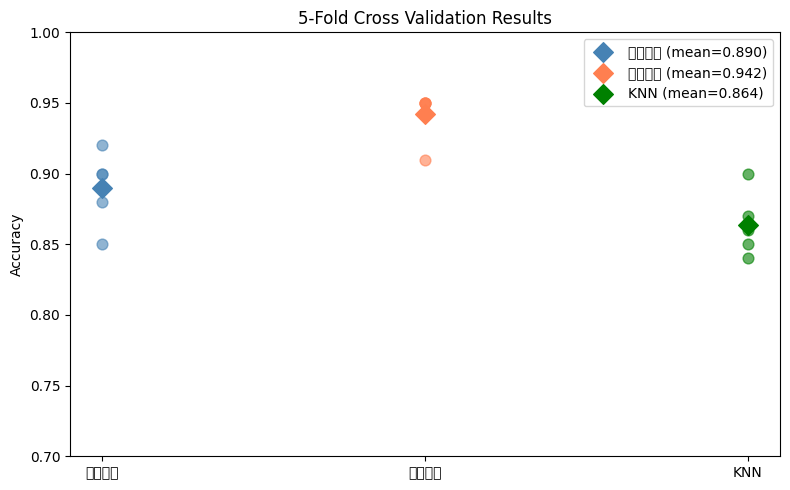

In [3]:
# 視覺化各模型的交叉驗證結果
fig, ax = plt.subplots(figsize=(8, 5))

positions = range(len(models))
for i, (name, scores) in enumerate(results.items()):
    ax.scatter([i]*5, scores, alpha=0.6,
               color=['steelblue', 'coral', 'green'][i], s=60)
    ax.scatter(i, scores.mean(), marker='D', s=100,
               color=['steelblue', 'coral', 'green'][i],
               zorder=5, label=f'{name} (mean={scores.mean():.3f})')

ax.set_xticks(positions)
ax.set_xticklabels(models.keys())
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross Validation Results')
ax.legend()
ax.set_ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

## 2. 我的學習筆記

1. 這個主題在做什麼：
   用 K-Fold 讓每筆資料都被當過測試集，
   得到更可靠的模型評估結果。

2. 標準差的意義：
   標準差越小 = 模型越穩定
   標準差越大 = 模型對資料切法很敏感

3. 我覺得最難理解的地方：
   交叉比較執行程序

4. 這個跟我研究的連結：
   運動員資料通常樣本數不多，
   交叉驗證可以讓每筆資料都被充分利用，
   這在樣本有限的運動科學研究中特別重要。